# 03: Replication of previous results

Train a simple CNN to classify Control vs Chemoresistant using only the 2 original files (CNTL-MB231, TAMO-MB231). We split by tile to avoid data leakage within a file.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import sys
sys.path.insert(0, '/home/emartinl/chemores/scripts')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path

print(f"Using GPU: {os.environ['CUDA_VISIBLE_DEVICES']}")

Using GPU: 0


## Load data

Only the 2 original 15-timepoint files. Split by tile so cells from the same tile stay in the same set.

In [2]:
OUT_DIR = Path("/baldig/bioprojects2/emartinl/chemores/preprocessed_phasor")

X_cntl = np.load(OUT_DIR / "CNTL-MB231_cells.npy", mmap_mode="r")
X_tamo = np.load(OUT_DIR / "TAMO-MB231_cells.npy", mmap_mode="r")

meta_cntl = pd.read_csv(OUT_DIR / "CNTL-MB231_cells_meta.csv")
meta_tamo = pd.read_csv(OUT_DIR / "TAMO-MB231_cells_meta.csv")

meta = pd.concat([meta_cntl, meta_tamo], ignore_index=True)
meta["y"] = (meta["group"] == "Chemoresistant").astype(int)

print(f"Control: {len(meta_cntl)}, Chemoresistant: {len(meta_tamo)}")
print(f"Total: {len(meta)}")

# tile-based split
train_idx, test_idx = [], []
for group in ["Control", "Chemoresistant"]:
    gm = meta[meta["group"] == group]
    tiles = gm["tile"].unique()
    tr_tiles, te_tiles = train_test_split(tiles, test_size=0.2, random_state=42)
    train_idx.extend(gm[gm["tile"].isin(tr_tiles)].index)
    test_idx.extend(gm[gm["tile"].isin(te_tiles)].index)

train_idx, test_idx = np.array(train_idx), np.array(test_idx)
print(f"Train: {len(train_idx)}, Test: {len(test_idx)}")

Control: 4500, Chemoresistant: 5750
Total: 10250
Train: 8200, Test: 2050


In [3]:
class CellDataset(Dataset):
    def __init__(self, meta, indices, X_cntl, X_tamo):
        self.meta = meta.iloc[indices].reset_index(drop=True)
        self.X_cntl = X_cntl
        self.X_tamo = X_tamo

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        x = self.X_cntl[row["cell_id"]] if row["group"] == "Control" else self.X_tamo[row["cell_id"]]
        x = torch.tensor(x, dtype=torch.float32)
        x = (x - x.mean()) / (x.std() + 1e-6)
        y = torch.tensor(row["y"], dtype=torch.long)
        return x, y

train_loader = DataLoader(CellDataset(meta, train_idx, X_cntl, X_tamo),
                          batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(CellDataset(meta, test_idx,  X_cntl, X_tamo),
                          batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

x, y = next(iter(train_loader))
print(f"Batch shape: {x.shape}, labels: {y.tolist()}")

Batch shape: torch.Size([16, 7, 512, 512]), labels: [1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0]


## Model

Simple 3-layer CNN: 7 input channels (dyes) → 3 conv blocks with max pooling → FC → 2 classes.

In [4]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(7, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 64 * 64, 128)  # after 3 pools: 512→256→128→64
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

device = torch.device("cuda:0")  # GPU 1 (after CUDA_VISIBLE_DEVICES=1)
model = SmallCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print(f"Device: {device}")

Device: cuda:0


In [5]:
def train_one_epoch(loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

for epoch in range(1):
    loss, train_acc = train_one_epoch(train_loader)
    test_acc = evaluate(test_loader)
    print(f"Epoch {epoch+1}: loss={loss:.4f}  train_acc={train_acc:.3f}  test_acc={test_acc:.3f}")

Epoch 1: loss=0.1421  train_acc=0.939  test_acc=1.000


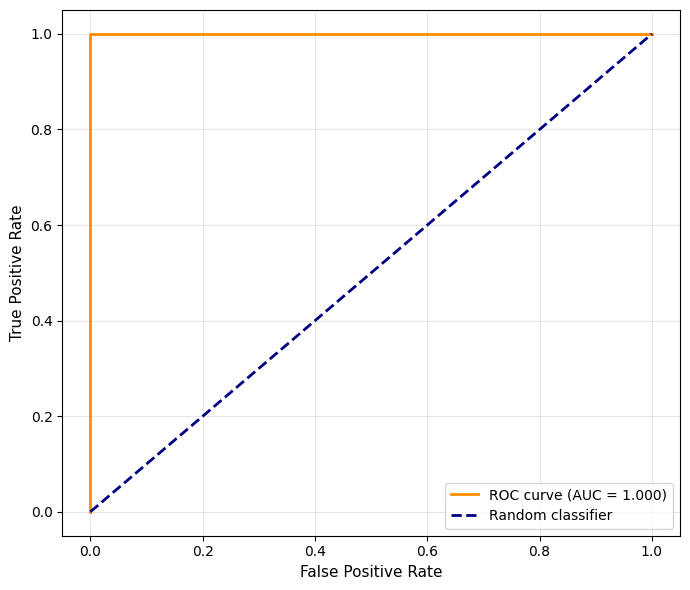

ROC AUC: 1.0000


In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predictions and probabilities on test set
model.eval()
y_true, y_probs = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # prob of class 1
        y_true.extend(y.numpy())
        y_probs.extend(probs)

y_true = np.array(y_true)
y_probs = np.array(y_probs)

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_03_modeling.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

## Sanity check: shuffled labels

If we shuffle the labels and retrain, accuracy should drop to ~50% (random). If it doesn't, something is wrong.

In [ ]:
meta_shuf = meta.copy()
meta_shuf["y"] = np.random.permutation(meta_shuf["y"].values)

train_loader_shuf = DataLoader(CellDataset(meta_shuf, train_idx, X_cntl, X_tamo),
                               batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
test_loader_shuf  = DataLoader(CellDataset(meta_shuf, test_idx,  X_cntl, X_tamo),
                               batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

# fresh model
model = SmallCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

loss, train_acc = train_one_epoch(train_loader_shuf)
test_acc = evaluate(test_loader_shuf)
print(f"Shuffled labels → train_acc={train_acc:.3f}  test_acc={test_acc:.3f}")

Shuffled labels → train_acc=0.552  test_acc=0.566
